In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Required Functions: Static Tolling

### Revenue

In [ ]:
def revenue_static_mfd(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D):
    '''
    Computes the revenue under the MFD for any static toll \tau at which both
    cars and transit are used at equilibrium
    '''

    helper1 = jam_density / ((jam_density / service_rate) + ((z_T - z_C - tau)/D))
    term1 = (num_users / arrival_rate) * helper1
    term2 = jam_density * D * ((e + L) / (e * L)) * np.log(1 + ((z_T - z_C - tau) * service_rate/(jam_density * D))) * (1 - helper1 / arrival_rate)
    revenue = tau * (term1 + term2)

    return revenue

In [ ]:
def revenue_z_T_minus_z_C_static(z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D):
    '''
    Computes the revenue under the MFD for a static toll z_T - z_C
    '''
    revenue = (z_T - z_C) * num_users * service_rate / arrival_rate

    return revenue

### System Cost

In [ ]:
def integrand1(delta_, tau, z_T, z_C, num_users, arrival_rate, service_rate, schedule_penalty, jam_density, D):

    helper_int = jam_density / ((jam_density / service_rate) + ((z_T - z_C - tau - (schedule_penalty * delta_) )/D))


    return helper_int * (z_T - z_C - tau - (schedule_penalty * delta_))


def integrate_integrand1(tau, z_T, z_C, num_users, arrival_rate, service_rate,
                         schedule_penalty, jam_density, D,
                         atol=1e-9, rtol=1e-7, max_subdiv=200,
                         fallback_grid=5000):
    """
    Returns (value, err_est) where:
      value   = ∫_{0}^{U} integrand1(δ, ...) dδ
      err_est = error estimate (from quad) or np.nan if using fallback

    Notes:
    - If U <= 0 (i.e., z_T - z_C - tau <= 0), returns (0.0, 0.0).
    - Raises ValueError if schedule_penalty <= 0.
    """
    U = (z_T - z_C - tau) / schedule_penalty

    # Try SciPy adaptive integration first
    try:
        from scipy.integrate import quad

        def f(delta_):
            return integrand1(
                delta_, tau, z_T, z_C, num_users, arrival_rate, service_rate,
                schedule_penalty, jam_density, D
            )

        val, err = quad(f, 0.0, U, epsabs=atol, epsrel=rtol, limit=max_subdiv)
        return float(val), float(err)

    except Exception:
        # Fallback: composite trapezoidal rule on an even grid
        deltas = np.linspace(0.0, U, fallback_grid)
        vals = np.array([
            integrand1(
                d, tau, z_T, z_C, num_users, arrival_rate, service_rate,
                schedule_penalty, jam_density, D
            )
            for d in deltas
        ])
        val = np.trapz(vals, deltas)
        return float(val), float('nan')

In [ ]:
def system_cost_ub_static(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D):
    '''
    Computes the revenue under the MFD for a static toll z_T - z_C
    '''
    helper1 = jam_density / ((jam_density / service_rate) + ((z_T - z_C - tau)/D))
    helper2 = jam_density * D * ((e + L) / (e * L)) * np.log(1 + ((z_T - z_C - tau) * service_rate/(jam_density * D)))
    terma = (num_users / arrival_rate) * helper1
    termb = helper2 * (1 - helper1 / arrival_rate)

    t_C_minus_t_B = (num_users / arrival_rate) - (1 / arrival_rate) * helper2

    helper3 = (jam_density * D / e) * np.log(1 + ((z_T - z_C - tau) * service_rate/(jam_density * D)))
    helper4 = (jam_density * D / L) * np.log(1 + ((z_T - z_C - tau) * service_rate/(jam_density * D)))

    if z_T - z_C - tau > 0:
        earliness_helper1 = np.log(1 + ((z_T - z_C - tau) * service_rate/(jam_density)))
        earliness_helper2 = z_T - z_C - tau - ((jam_density)/arrival_rate) * earliness_helper1
        earliness_helper3 = 1 - ((jam_density)/(service_rate * (z_T - z_C - tau))) * earliness_helper1
        schedule_cost = jam_density * ((e + L) / (e * L)) * earliness_helper2 * earliness_helper3
    else:
        schedule_cost = 0

    #t_1_minus_t_A = ((z_T - z_C - tau) / arrival_rate) - (1 / arrival_rate) * helper3
    #t_D_minus_t_2 = ((z_T - z_C - tau) / arrival_rate) - (1 / arrival_rate) * helper4

    transit_cost = z_T * (num_users - terma - termb)
    ff_car_cost = z_C * (terma + termb)
    on_time_car_waiting_cost = t_C_minus_t_B * helper1 * (z_T - z_C - tau)
    early_user_waiting_cost, _ = integrate_integrand1(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, jam_density, D)
    late_user_waiting_cost, _ = integrate_integrand1(tau, z_T, z_C, num_users, arrival_rate, service_rate, L, jam_density, D)
    # early_cost_ub = e * t_1_minus_t_A * helper3
    # late_cost_ub = L * t_D_minus_t_2 * helper4

    total_cost = transit_cost + ff_car_cost + on_time_car_waiting_cost + early_user_waiting_cost + late_user_waiting_cost + schedule_cost#early_cost_ub + late_cost_ub

    return total_cost

In [ ]:
def system_cost_z_T_z_C(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the system cost under the MFD for the toll z_T - z_C
    '''
    ff_car_cost = z_C * num_users * (service_rate / arrival_rate)
    transit_cost = z_T * num_users * (1 - (service_rate / arrival_rate))

    return ff_car_cost + transit_cost

## Required Functions: Dynamic Tolling

### Revenue

In [ ]:
def dynamic_optimal_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the optimal dynamic revenue for any set of parameter values
  '''
  T_C = (num_users * e * L)/(service_rate * (e + L))

  if z_T - z_C <= T_C * arrival_rate /(arrival_rate - service_rate):
    revenue = (z_T - z_C) * num_users * service_rate/arrival_rate + ((z_T - z_C)**2)* service_rate * (e+L)/(2*e*L) * ((1 - service_rate/arrival_rate)**2)
  else:
    revenue = (z_T - z_C) * num_users - (((num_users)**2) / (2 * service_rate)) * (e * L)/(e + L)

  return revenue

In [ ]:
def dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the optimal fraction of time the toll is set to z_T - z_C under
    the dynamic revenue optimal tolling policy
    '''

    return max( 1 - (z_T - z_C) * service_rate * (e + L) / (num_users * e * L) * (1 - (service_rate / arrival_rate)) , 0)

In [ ]:
def sc_opt_dyn_toll_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the revenue corresponding to the dynamic system cost minimizing
    tolling policy
    '''

    T_C = (num_users * e * L)/(service_rate * (e + L))

    if z_T - z_C <= T_C:
        term1 = (service_rate / 2) * ((z_T - z_C)**2) * (1/e + 1/L)
        term2 = (z_T - z_C) * (1 - ((z_T - z_C)/T_C)) * num_users * service_rate / arrival_rate
        revenue = term1 + term2
    else:
        revenue = (z_T - z_C) * num_users - (((num_users)**2) / (2 * service_rate)) * (e * L)/(e + L)

    return revenue

### System Cost

In [ ]:
def system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the system optimum cost
    '''
    T_C = (num_users * e * L)/(service_rate * (e + L))

    if z_T - z_C <= T_C:
      baseline_cost = z_C * num_users * (service_rate / arrival_rate) + z_T * num_users * (1 - (service_rate / arrival_rate))
      correction_term = (1 - (service_rate / arrival_rate)) * (service_rate * (e + L) / (2 * e * L)) * ((z_T - z_C)**2)

      system_cost = baseline_cost - correction_term

    else:
      #everyone users a car at the system optimum solution
      system_cost = z_C * num_users + (e * L) / (2 * (e + L)) * (num_users**2) * (1/service_rate - 1/arrival_rate)

    return system_cost

In [ ]:
def system_cost_dynamic(z_C, z_T, num_users, arrival_rate, service_rate, e, L, frac):
    '''
    Computes the system cost corresponding to the dynamic revenue tolling
    policy where frac is the fraction of time spent with a toll of z_T - z_C
    under a dynamic tolling policy with a mis-specified Lambda
    '''

    term1 = z_T * (frac * num_users * (1 - service_rate / arrival_rate))
    term2 = z_C * ((frac * num_users * service_rate / arrival_rate) + (1 - frac) * num_users)
    term3 = ((num_users ** 2) * e * L) / (2 * service_rate * (e + L)) * ((1 - frac)**2) * (1 - service_rate / arrival_rate)

    return term1 + term2 + term3

## Experiment: Comparing Static to Dynamic Revenues

### Parameter Initialization

In [ ]:
# VoT Parameters
e = 0.61 # Relative value of being early
L = 2.4 # Relative value of being late
c_w = 40 # $/hr cost of waiting

# Average length of trips D
D = 6 #in kilometers

# z_C estimate
avg_tt = 6/40 #Distance (km) / free flow speed (in kph)
parking_fee = 30
car_cost = avg_tt * c_w + parking_fee
z_C = car_cost / c_w

# z_T calibration
subway_avg_fare = 3
avg_walking_time = 2/6
half_avg_headway = 2.5/60
avg_trip_time = 12 / 60
time_costs = avg_walking_time + half_avg_headway + avg_trip_time

def subway_cost_(multiplier):
  '''
  Returns the cost of using subway given a discomfort multiplier
  '''

  subway_cost = subway_avg_fare + time_costs * c_w * multiplier

  return subway_cost

# Num Users
car_ridership = 200000 #Assumed to be 120,000 (avg vehicle entries) * 2 for vehicles plying in city center
subway_ridership = 700000 #Assumed to be
num_users = car_ridership + subway_ridership

# Arrival_rate
arrival_rate = num_users / 5

# MFD Calibration
service_rate = 45000 #100000 / 5 # used as 785 * 12 * 22.5 / 10
jam_density = 140000

### Revenue Comparisons

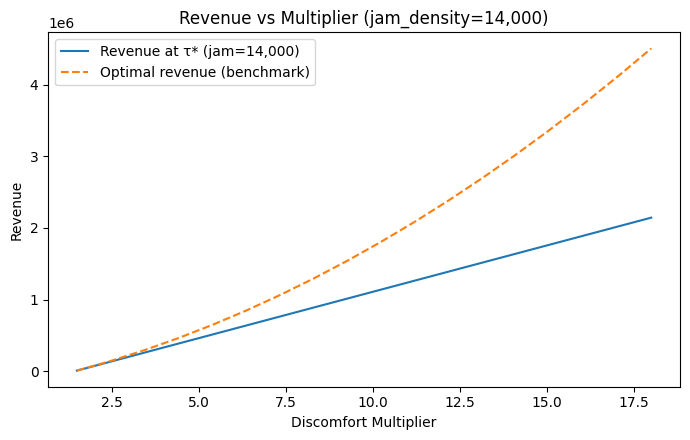

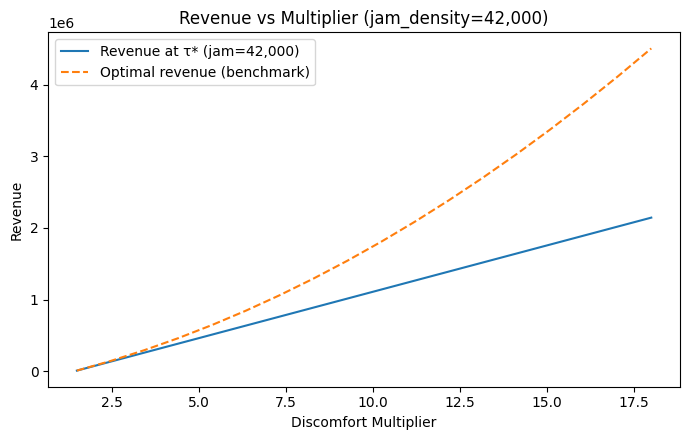

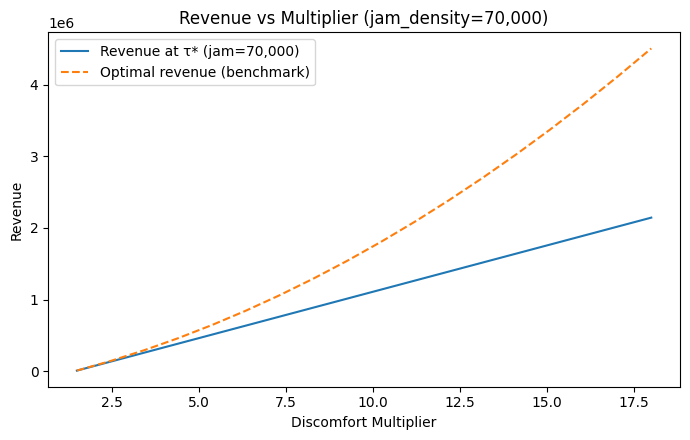

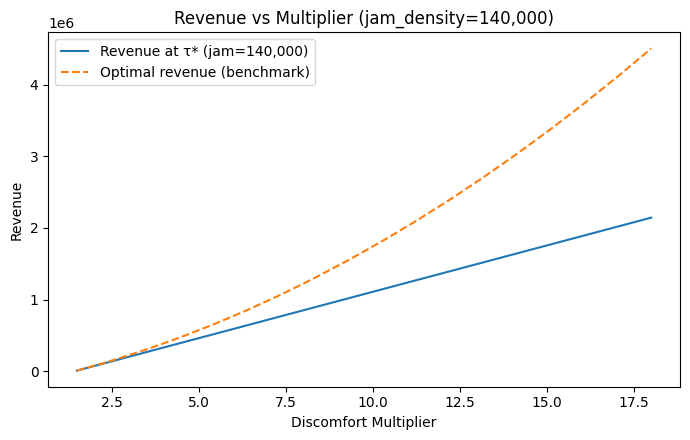

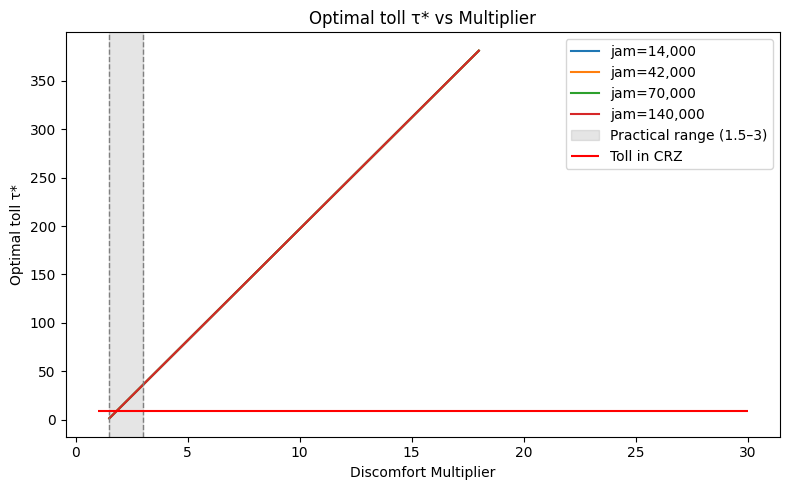

In [ ]:
T_C = (num_users * e * L)/(service_rate * (e + L))

multiplier_max = 18 #(c_w * (z_C + T_C) - subway_avg_fare) / (time_costs * c_w)


multipliers = np.linspace(1.5, multiplier_max, 18)  # 18 points: 1.5, 2.0, …, 10.0
jam_densities = [14000, 42000, 70000, 140000]
# Grid search resolution for tau (increase for higher accuracy, slower runtime)
tau_grid_points = 400

def find_optimal_tau(z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D,
                     grid_points=tau_grid_points):
    """
    Grid search over tau ∈ [0, max(0, z_T - z_C)] to maximize revenue_(...).
    Returns (tau_star, rev_star).
    """
    upper = max(0.0, z_T - z_C)
    if upper == 0:
        # No feasible positive toll
        rev0 = revenue_static_mfd(0.0, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, 1)
        return 0.0, rev0

    tau_grid = np.linspace(0.0, upper, grid_points)
    best_rev = -np.inf
    best_tau = 0.0
    for tau in tau_grid:
        rev = revenue_static_mfd(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, 1)
        if rev > best_rev:
            best_rev = rev
            best_tau = float(tau) * c_w
    return best_tau, best_rev


def compute_series_for_jam_density(jam_density):
    """
    For a given jam_density, sweep multipliers:
      - compute z_T via cost_(multiplier)
      - compute tau* and achieved revenue at tau*
      - compute optimal_revenue benchmark
    Returns dict with arrays: multipliers, z_Ts, tau_stars, revs_at_tau_star, revs_opt
    """
    z_Ts = []
    tau_stars = []
    revs_at_tau_star = []
    revs_opt = []

    for m in multipliers:
        z_T = subway_cost_(m) / c_w
        z_Ts.append(z_T)

        tau_star, rev_star = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jam_density,
            D=1
        )
        tau_stars.append(tau_star)
        revs_at_tau_star.append(rev_star)

        rev_opt = dynamic_optimal_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
        revs_opt.append(rev_opt)

    rev_ratio = np.array(revs_at_tau_star) / np.array(revs_opt)
    return {
        "multipliers": np.array(multipliers),
        "z_Ts": np.array(z_Ts),
        "tau_stars": np.array(tau_stars),
        "revs_at_tau_star": np.array(revs_at_tau_star),
        "revs_opt": np.array(revs_opt),
        "rev_ratio": rev_ratio,
        "jam_density": jam_density,
    }


# ----------------------------
# RUN + PLOTS
# ----------------------------
all_results = []
for jd in jam_densities:
    all_results.append(compute_series_for_jam_density(jd))

# Plot 1: Revenue at tau* vs Optimal Revenue (per jam_density)
for res in all_results:
    m = res["multipliers"]
    plt.figure(figsize=(7, 4.5))
    plt.plot(m, res["revs_at_tau_star"], label=f"Revenue at τ* (jam={res['jam_density']:,})")
    plt.plot(m, res["revs_opt"], linestyle="--", label="Optimal revenue (benchmark)")
    plt.xlabel("Discomfort Multiplier")
    plt.ylabel("Revenue")
    plt.title(f"Revenue vs Multiplier (jam_density={res['jam_density']:,})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot 2: τ* vs multiplier (per jam_density)
plt.figure(figsize=(8, 5))
for res in all_results:
    plt.plot(res["multipliers"], res["tau_stars"], label=f"jam={res['jam_density']:,}")
plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.5–3)")
plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(3, color='gray', linestyle='--', linewidth=1)
plt.hlines(
                y=9,            # y-value of the line
                xmin=1,         # start x
                xmax=30,       # end x
                colors="red",   # line color
                #linestyles="-",# dashed style
                label="Toll in CRZ"
            )
plt.xlabel("Discomfort Multiplier")
plt.ylabel("Optimal toll τ*")
plt.title("Optimal toll τ* vs Multiplier")
plt.legend()
plt.tight_layout()
plt.show()

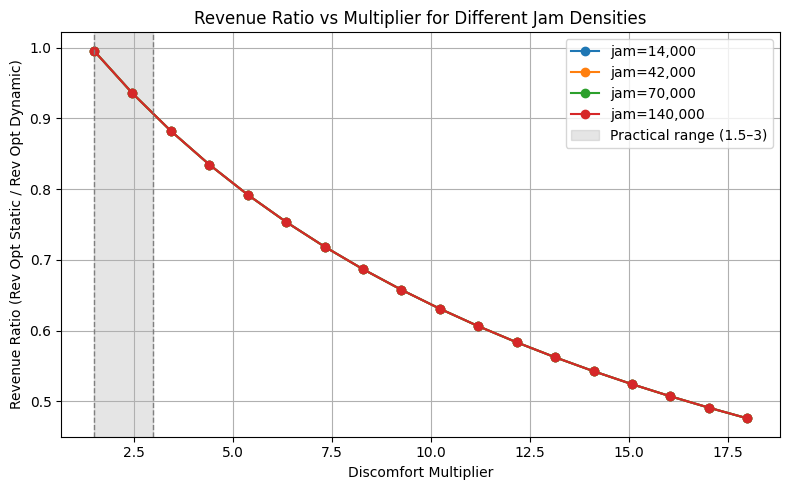

In [ ]:
# --- Plot 3: Revenue Ratio (Revenue_at_tau* / Optimal_Revenue)
plt.figure(figsize=(8, 5))
for res in all_results:
    plt.plot(res["multipliers"], res["rev_ratio"], marker='o', label=f"jam={res['jam_density']:,}")
plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.5–3)")
plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(3, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Discomfort Multiplier")
plt.ylabel("Revenue Ratio (Rev Opt Static / Rev Opt Dynamic)")
plt.title("Revenue Ratio vs Multiplier for Different Jam Densities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

140000

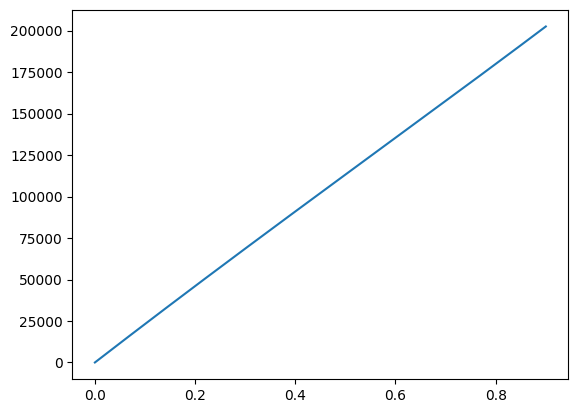

In [ ]:
rev_val = []
tau_grid = np.linspace(0.0, 0.9, 400)
best_rev = -np.inf
best_tau = 0.0
for tau in tau_grid:
    rev_val.append(revenue_static_mfd(tau, 2*0.9, 0.9, 900000, 180000, 45000, e, L, 140000, 1))

plt.plot(tau_grid, rev_val)
jam_density

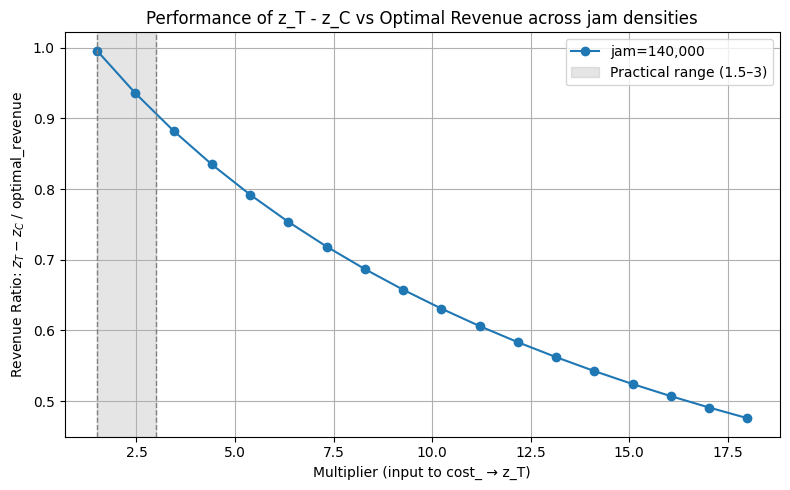

In [ ]:
multipliers = np.linspace(1.5, multiplier_max, 18)  # 18 points: 1.5, 2.0, …, 10.0

# --- Add this alongside your previous imports/config ---
# (Assumes revenue_a, optimal_revenue, cost_, and the constants are already defined)

def compute_series_for_jam_density_with_a(jam_density):
    """
    Extends the earlier compute_series_for_jam_density by also computing:
      - rev_a: revenue under your 'revenue_a' policy
      - ratio_a: rev_a / optimal_revenue
    """
    z_Ts, tau_stars, revs_at_tau_star, revs_opt = [], [], [], []
    revs_a = []

    for m in multipliers:
        z_T = subway_cost_(m) / c_w
        z_Ts.append(z_T)

        # 1) Optimal tau via grid search for reference (optional: remove if not needed here)
        tau_star, rev_star = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jam_density,
            D=1
        )
        tau_stars.append(tau_star)
        revs_at_tau_star.append(rev_star)

        # 2) Optimal revenue benchmark
        rev_opt = dynamic_optimal_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
        revs_opt.append(rev_opt)

        # 3) Revenue under your specific toll policy
        rev_a = revenue_z_T_minus_z_C_static(z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, 1)
        revs_a.append(rev_a)

    revs_opt = np.array(revs_opt)
    # Guard against divide-by-zero if any optimal_revenue returns 0
    safe_opt = np.where(revs_opt == 0, np.nan, revs_opt)
    ratio_a = np.array(revs_a) / safe_opt

    return {
        "multipliers": np.array(multipliers),
        "z_Ts": np.array(z_Ts),
        "tau_stars": np.array(tau_stars),
        "revs_at_tau_star": np.array(revs_at_tau_star),
        "revs_opt": revs_opt,
        "revs_a": np.array(revs_a),
        "ratio_a": ratio_a,
        "jam_density": jam_density,
    }

# --- Run the computations ---
all_results_a = [compute_series_for_jam_density_with_a(jd) for jd in jam_densities]

# --- Plot: Revenue_a / Optimal_Revenue vs Multiplier, lines by jam density ---
plt.figure(figsize=(8, 5))
for res in all_results_a:
    plt.plot(res["multipliers"], res["ratio_a"], marker='o', label=f"jam={res['jam_density']:,}")
plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.5–3)")
plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(3, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Multiplier (input to cost_ → z_T)")
plt.ylabel("Revenue Ratio: $z_T - z_C$ / optimal_revenue")
plt.title("Performance of z_T - z_C vs Optimal Revenue across jam densities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


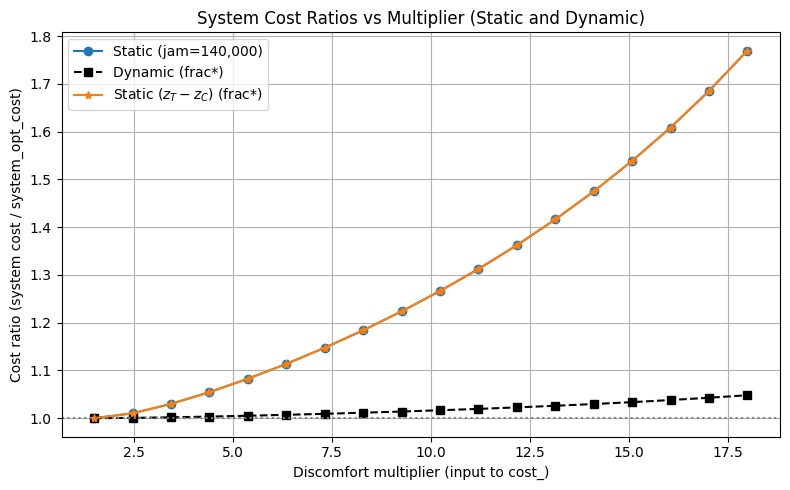

In [ ]:
# -----------------------------------
# DYNAMIC RATIO (independent of jam_density per your signatures)
# ratio_dynamic = system_cost_dynamic(frac*) / system_opt_cost
# -----------------------------------
ratio_dynamic = []
ratio_z_T_z_C = []
for m in multipliers:
    z_T = subway_cost_(m) / c_w
    opt_cost = system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L)
    z_T_z_C_cost = system_cost_z_T_z_C(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
    frac = dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
    dyn_cost = system_cost_dynamic(z_C, z_T, num_users, arrival_rate, service_rate, e, L, frac)
    ratio_dynamic.append(dyn_cost/opt_cost)
    ratio_z_T_z_C.append(z_T_z_C_cost/opt_cost)
ratio_dynamic = np.array(ratio_dynamic)

jam_densities = [140000]

# -----------------------------------
# STATIC RATIO USING YOUR find_optimal_tau
# ratio_static(jd) = system_cost_ub_static(τ*; jd) / system_opt_cost
# -----------------------------------
results_static = []
for jd in jam_densities:
    tau_stars = []
    ratio_static = []
    for m in multipliers:
        z_T = subway_cost_(m) / c_w

        # Use your previously defined helper:
        tau_star, _ = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jd,
            D=1
        )
        tau_stars.append(tau_star)

        opt_cost = system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L)
        static_cost = system_cost_ub_static(
            tau_star / c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jd, 1
        )

        #print(static_cost, opt_cost)
        ratio_static.append(static_cost/opt_cost)

    results_static.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "tau_stars": np.array(tau_stars),
        "ratio_static": np.array(ratio_static),
    })

# -----------------------------------
# PLOTS
# -----------------------------------

plt.figure(figsize=(8,5))

# Plot static ratios (one per jam density)
for res in results_static:
    plt.plot(
        res["multipliers"], res["ratio_static"],
        marker='o', linestyle='-',
        label=f"Static (jam={res['jam_density']:,})"
    )

# Plot dynamic ratio (same across jam densities)
plt.plot(
    multipliers, ratio_dynamic,
    marker='s', linestyle='--', color='black',
    label="Dynamic (frac*)"
)

plt.plot(multipliers, ratio_z_T_z_C,
    marker='*',
    label="Static ($z_T - z_C$) (frac*)")

# Formatting
plt.axhline(1.0, linestyle=':', color='gray')

plt.xlabel("Discomfort multiplier (input to cost_)")
plt.ylabel("Cost ratio (system cost / system_opt_cost)")
plt.title("System Cost Ratios vs Multiplier (Static and Dynamic)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

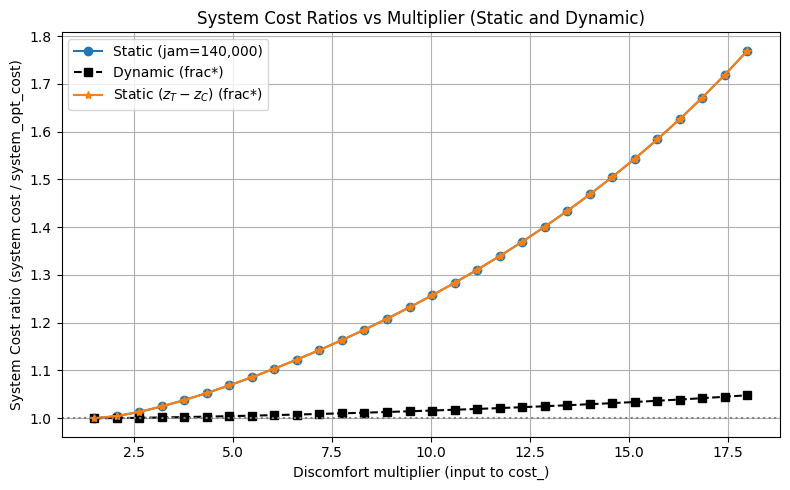

In [ ]:
# -----------------------------------
# DYNAMIC RATIO (independent of jam_density per your signatures)
# ratio_dynamic = system_cost_dynamic(frac*) / system_opt_cost
# -----------------------------------
ratio_dynamic = []
ratio_z_T_z_C = []
for m in multipliers:
    z_T = subway_cost_(m) / c_w
    opt_cost = system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L)
    z_T_z_C_cost = system_cost_z_T_z_C(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
    frac = dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
    dyn_cost = system_cost_dynamic(z_C, z_T, num_users, arrival_rate, service_rate, e, L, frac)
    ratio_dynamic.append(dyn_cost/opt_cost)
    ratio_z_T_z_C.append(z_T_z_C_cost/opt_cost)
ratio_dynamic = np.array(ratio_dynamic)

# -----------------------------------
# STATIC RATIO USING YOUR find_optimal_tau
# ratio_static(jd) = system_cost_ub_static(τ*; jd) / system_opt_cost
# -----------------------------------
results_static = []
for jd in jam_densities:
    tau_stars = []
    ratio_static = []
    for m in multipliers:
        z_T = subway_cost_(m) / c_w

        # Use your previously defined helper:
        tau_star, _ = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jd,
            D=1
        )
        tau_stars.append(tau_star)

        opt_cost = system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L)
        static_cost = system_cost_ub_static(
            tau_star / c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jd, 1
        )

        #print(static_cost, opt_cost)
        ratio_static.append(static_cost/opt_cost)

    results_static.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "tau_stars": np.array(tau_stars),
        "ratio_static": np.array(ratio_static),
    })

# -----------------------------------
# PLOTS
# -----------------------------------

plt.figure(figsize=(8,5))

# Plot static ratios (one per jam density)
for res in results_static:
    plt.plot(
        res["multipliers"], res["ratio_static"],
        marker='o', linestyle='-',
        label=f"Static (jam={res['jam_density']:,})"
    )

# Plot dynamic ratio (same across jam densities)
plt.plot(
    multipliers, ratio_dynamic,
    marker='s', linestyle='--', color='black',
    label="Dynamic (frac*)"
)

plt.plot(multipliers, ratio_z_T_z_C,
    marker='*',
    label="Static ($z_T - z_C$) (frac*)")

# Formatting
plt.axhline(1.0, linestyle=':', color='gray')
plt.xlabel("Discomfort multiplier (input to cost_)")
plt.ylabel("System Cost ratio (system cost / system_opt_cost)")
plt.title("System Cost Ratios vs Multiplier (Static and Dynamic)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

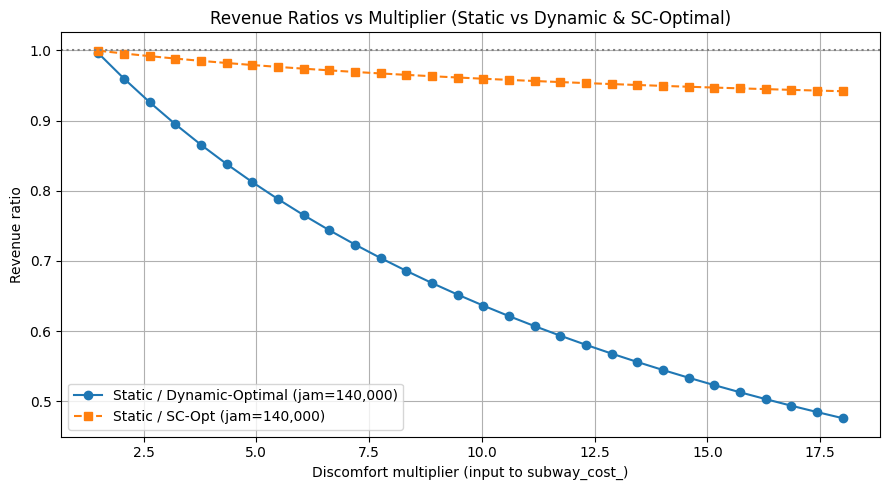

In [ ]:
rev_ratio_to_dyn = []  # list of dicts per jam density
rev_ratio_to_sc  = []

jam_densities = [140000]

for jd in jam_densities:
    r_to_dyn = []
    r_to_sc  = []
    for m in multipliers:
        z_T = subway_cost_(m) / c_w

        tau_star, _ = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jd,
            D=1
        )

        rev_static = revenue_static_mfd(
            tau_star / c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jd, 1
        )
        rev_dyn_opt = dynamic_optimal_revenue(
            z_T, z_C, num_users, arrival_rate, service_rate, e, L
        )
        rev_sc_opt = sc_opt_dyn_toll_revenue(
            z_T, z_C, num_users, arrival_rate, service_rate, e, L
        )

        r_to_dyn.append(rev_static / rev_dyn_opt)
        r_to_sc.append(rev_sc_opt / rev_dyn_opt)

    rev_ratio_to_dyn.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "ratio": np.array(r_to_dyn),
    })
    rev_ratio_to_sc.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "ratio": np.array(r_to_sc),
    })

# ---------- single combined plot ----------
plt.figure(figsize=(9,5))

# Static vs dynamic-optimal revenue (solid lines, one per jam density)
for res in rev_ratio_to_dyn:
    plt.plot(
        res["multipliers"], res["ratio"],
        marker='o', linestyle='-',
        label=f"Static / Dynamic-Optimal (jam={res['jam_density']:,})"
    )

# Static vs SC-opt dynamic-toll revenue (dashed lines, one per jam density)
for res in rev_ratio_to_sc:
    plt.plot(
        res["multipliers"], res["ratio"],
        marker='s', linestyle='--',
        label=f"Static / SC-Opt (jam={res['jam_density']:,})"
    )

plt.axhline(1.0, linestyle=':', color='gray')
plt.xlabel("Discomfort multiplier (input to subway_cost_)")
plt.ylabel("Revenue ratio")
plt.title("Revenue Ratios vs Multiplier (Static vs Dynamic & SC-Optimal)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


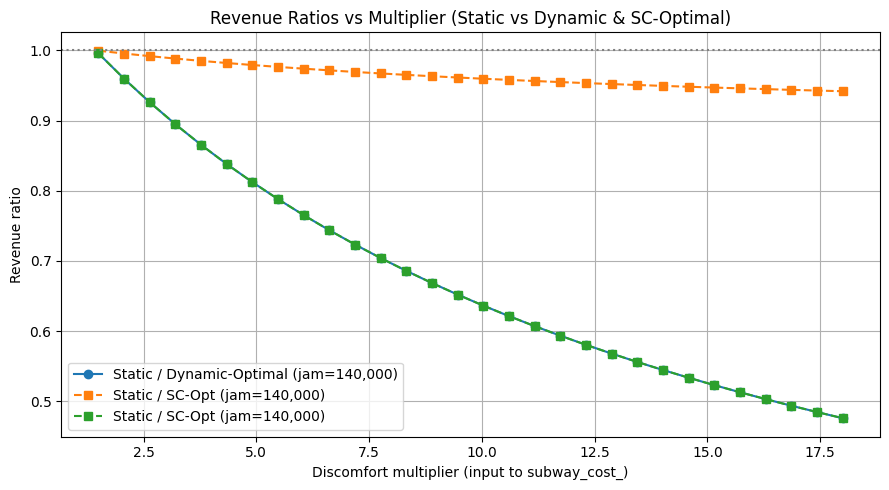

In [ ]:
rev_ratio_to_dyn = []  # list of dicts per jam density
rev_ratio_to_sc  = []
rev_ratio_static_sc_dyn  = []

jam_densities = [140000]

def find_optimal_tau_sc(z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D,
                     grid_points=tau_grid_points):
    """
    Grid search over tau ∈ [0, max(0, z_T - z_C)] to maximize revenue_(...).
    Returns (tau_star, rev_star).
    """
    upper = max(0.0, z_T - z_C)
    if upper == 0:
        # No feasible positive toll
        sc0 = system_cost_ub_static(0.0, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, 1)
        return 0.0, sc0

    tau_grid = np.linspace(0.0, upper, grid_points)
    best_sc = np.inf
    best_tau = 0.0
    for tau in tau_grid:
        sc = system_cost_ub_static(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, 1)
        if sc < best_sc:
            best_sc = sc
            best_tau = float(tau) * c_w
    return best_tau, best_sc

for jd in jam_densities:
    r_to_dyn = []
    r_to_sc  = []
    r_static_sc_to_dyn = []
    for m in multipliers:
        z_T = subway_cost_(m) / c_w

        tau_star, _ = find_optimal_tau(
            z_T=z_T,
            z_C=z_C,
            num_users=num_users,
            arrival_rate=arrival_rate,
            service_rate=service_rate,
            e=e,
            L=L,
            jam_density=jd,
            D=1
        )

        tau_star_sc, _ = find_optimal_tau_sc(z_T, z_C, num_users, arrival_rate, service_rate, e, L, jam_density, D,
                     grid_points=tau_grid_points)
        print(tau_star_sc == tau_star)

        rev_static = revenue_static_mfd(
            tau_star / c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jd, 1
        )
        rev_dyn_opt = dynamic_optimal_revenue(
            z_T, z_C, num_users, arrival_rate, service_rate, e, L
        )
        rev_sc_opt = sc_opt_dyn_toll_revenue(
            z_T, z_C, num_users, arrival_rate, service_rate, e, L
        )

        rev_static_sc_opt = revenue_static_mfd(
            tau_star_sc / c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L, jd, 1
        )

        r_to_dyn.append(rev_static / rev_dyn_opt)
        r_to_sc.append(rev_sc_opt / rev_dyn_opt)
        r_static_sc_to_dyn.append(rev_static_sc_opt / rev_dyn_opt)

    rev_ratio_to_dyn.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "ratio": np.array(r_to_dyn),
    })
    rev_ratio_to_sc.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "ratio": np.array(r_to_sc),
    })
    rev_ratio_static_sc_dyn.append({
        "jam_density": jd,
        "multipliers": multipliers.copy(),
        "ratio": np.array(r_static_sc_to_dyn),
    })

# ---------- single combined plot ----------
plt.figure(figsize=(9,5))

# Static vs dynamic-optimal revenue (solid lines, one per jam density)
for res in rev_ratio_to_dyn:
    plt.plot(
        res["multipliers"], res["ratio"],
        marker='o', linestyle='-',
        label=f"Static / Dynamic-Optimal (jam={res['jam_density']:,})"
    )

# Static vs SC-opt dynamic-toll revenue (dashed lines, one per jam density)
for res in rev_ratio_to_sc:
    plt.plot(
        res["multipliers"], res["ratio"],
        marker='s', linestyle='--',
        label=f"Static / SC-Opt (jam={res['jam_density']:,})"
    )

for res in rev_ratio_static_sc_dyn:
    plt.plot(
        res["multipliers"], res["ratio"],
        marker='s', linestyle='--',
        label=f"Static / SC-Opt (jam={res['jam_density']:,})"
    )

plt.axhline(1.0, linestyle=':', color='gray')
plt.xlabel("Discomfort multiplier (input to subway_cost_)")
plt.ylabel("Revenue ratio")
plt.title("Revenue Ratios vs Multiplier (Static vs Dynamic & SC-Optimal)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()